# Vendor Performance Analysis
### Inventory & Vendor Performance Project | 2024

This notebook performs a comprehensive analysis of vendor and product 
performance using the `vendor_sales_summary` table built by `get_vendor_summary.py`.

### Analysis Structure
1. Dataset Overview
2. Vendor Performance — Top & Bottom Performers
3. Profitability Analysis
4. Pareto Analysis — Which vendors drive 80% of revenue
5. Product Level Analysis
6. Inventory Efficiency — Stock Turnover
7. Freight Cost Impact
8. Statistical Testing — Is there a significant difference between top and low performers

In [1]:
# ─────────────────────────────────────────────
# IMPORTS & DATABASE CONNECTION
# ─────────────────────────────────────────────
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

conn = sqlite3.connect('../inventory.db')
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)

print(f"Shape: {df.shape}")
print(f"Connected successfully")

Shape: (10514, 27)
Connected successfully


In [8]:
# ─────────────────────────────────────────────
# VISUALIZATION STYLE CONFIGURATION
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# Color palette
COLORS = {
    'primary'    : '#2C6E9B',
    'secondary'  : '#E8794A',
    'success'    : '#3DAA6D',
    'danger'     : '#D94F4F',
    'warning'    : '#F0B429',
    'light'      : '#F7F9FC',
    'dark'       : '#1A1A2E',
    'muted'      : '#8395A7'
}

PALETTE = [
    '#2C6E9B', '#E8794A', '#3DAA6D', '#D94F4F',
    '#F0B429', '#8E44AD', '#16A085', '#D35400',
    '#2980B9', '#27AE60'
]

# Global plot settings
rcParams['figure.dpi']          = 130
rcParams['figure.facecolor']    = 'white'
rcParams['axes.facecolor']      = '#F7F9FC'
rcParams['axes.edgecolor']      = '#CCCCCC'
rcParams['axes.linewidth']      = 0.8
rcParams['axes.spines.top']     = False
rcParams['axes.spines.right']   = False
rcParams['axes.grid']           = True
rcParams['grid.color']          = '#E0E0E0'
rcParams['grid.linewidth']      = 0.6
rcParams['grid.linestyle']      = '--'
rcParams['font.family']         = 'DejaVu Sans'
rcParams['axes.titlesize']      = 14
rcParams['axes.titleweight']    = 'bold'
rcParams['axes.titlepad']       = 15
rcParams['axes.labelsize']      = 11
rcParams['axes.labelcolor']     = '#333333'
rcParams['xtick.labelsize']     = 9
rcParams['ytick.labelsize']     = 9
rcParams['legend.framealpha']   = 0.9
rcParams['legend.edgecolor']    = '#CCCCCC'
rcParams['legend.fontsize']     = 9

def format_millions(x, pos):
    """Formatter for axis tick labels in millions."""
    return f'${x:.0f}M'

def add_value_labels(ax, bars, fmt='${:,.1f}M', divisor=1_000_000,
                     fontsize=8, color='#333333', padding=0.3):
    """Add value labels on top of bar charts."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            fmt.format(height / divisor),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, padding),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=fontsize, color=color, fontweight='bold'
        )

def style_axis(ax, title, xlabel='', ylabel='', legend=True):
    """Apply consistent styling to any axis."""
    ax.set_title(title, fontsize=14, fontweight='bold',
                 color=COLORS['dark'], pad=15)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color='#555555', labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color='#555555', labelpad=8)
    ax.tick_params(colors='#555555')
    if legend:
        ax.legend(framealpha=0.9, edgecolor='#CCCCCC')

print("Visualization style configured successfully")

Visualization style configured successfully


## 1. Dataset Overview

In [3]:
# ─────────────────────────────────────────────
# DATASET OVERVIEW
# ─────────────────────────────────────────────

print("=== Vendor Sales Summary — Overview ===\n")
print(f"Total Records          : {len(df):,}")
print(f"Unique Vendors         : {df['VendorNumber'].nunique()}")
print(f"Unique Brands          : {df['Brand'].nunique()}")
print(f"Total Purchase Spend   : ${df['TotalPurchaseDollars'].sum():>15,.2f}")
print(f"Total Sales Revenue    : ${df['TotalSalesDollars'].sum():>15,.2f}")
print(f"Total Gross Profit     : ${df['GrossProfit'].sum():>15,.2f}")
print(f"Total Net Profit       : ${df['NetProfit'].sum():>15,.2f}")
print(f"Total Excise Tax       : ${df['TotalExciseTax'].sum():>15,.2f}")
print(f"Total Freight Cost     : ${df['AllocatedFreightCost'].sum():>15,.2f}")
print(f"\nMedian Profit Margin   : {df['ProfitMargin%'].median():.2f}%")
print(f"Median Net Margin      : {df['NetProfitMargin%'].median():.2f}%")
print(f"Underperforming Records: {df['IsUnderperforming'].sum():,} "
      f"({df['IsUnderperforming'].mean()*100:.1f}%)")

print(f"\nPerformance Tier Distribution:")
print(df['PerformanceTier'].value_counts().to_string())

print(f"\nVolume Category Distribution:")
print(df['VolumeCategory'].value_counts().to_string())

=== Vendor Sales Summary — Overview ===

Total Records          : 10,514
Unique Vendors         : 124
Unique Brands          : 10485
Total Purchase Spend   : $ 321,618,581.88
Total Sales Revenue    : $ 451,620,183.69
Total Gross Profit     : $ 130,001,601.81
Total Net Profit       : $ 128,362,577.74
Total Excise Tax       : $  18,969,937.72
Total Freight Cost     : $   1,639,024.07

Median Profit Margin   : 30.78%
Median Net Margin      : 30.42%
Underperforming Records: 1,949 (18.5%)

Performance Tier Distribution:
PerformanceTier
Mid     5314
Low     2666
High    2534

Volume Category Distribution:
VolumeCategory
Standard(201-750ml)     8752
Magnum(1001-1750ml)      835
Miniature(≤200ml)        390
Large(751-1000ml)        374
Extra Large(>1750ml)     163


#### Dataset Overview — Key Observations

- **124 vendors** supplying **10,485 unique brands** across all stores
- **Total revenue of 451.6M dollars** against 321.6M dollars in purchases
- **Overall gross profit of 130M dollars** — 28.8% gross margin
- **Net profit of 128.4M dollars** after freight deduction — freight of 
  1.64M dollars is well controlled at only 0.36% of revenue
- **Excise tax of 19M dollars** — significant regulatory cost at 4.2% of revenue
- **Median profit margin of 30.78%** — healthy for liquor distribution. 
  Note: mean is not used here as it is heavily skewed by outliers
- **18.5% of records are underperforming** — flagged for separate analysis
- **Standard 750ml bottles dominate** at 83.2% of all product records

## 2. Vendor Performance Analysis

### 2.1 Top 10 Vendors by Revenue

In [4]:
# ─────────────────────────────────────────────
# TOP 10 VENDORS BY REVENUE
# Only using profitable records for fair comparison
# ─────────────────────────────────────────────

top_vendors = df[df['IsUnderperforming'] == False]\
    .groupby('VendorName')\
    .agg(
        TotalRevenue    = ('TotalSalesDollars',    'sum'),
        TotalPurchases  = ('TotalPurchaseDollars', 'sum'),
        GrossProfit     = ('GrossProfit',          'sum'),
        NetProfit       = ('NetProfit',            'sum'),
        AvgMargin       = ('ProfitMargin%',        'median'),
        TotalBrands     = ('Brand',                'nunique')
    )\
    .round(2)\
    .sort_values('TotalRevenue', ascending=False)\
    .head(10)\
    .reset_index()

# Format for display
display_df = top_vendors.copy()
for col in ['TotalRevenue', 'TotalPurchases', 'GrossProfit', 'NetProfit']:
    display_df[col] = display_df[col].apply(
        lambda x: f"${x/1_000_000:.2f}M"
    )
display_df['AvgMargin'] = display_df['AvgMargin'].apply(lambda x: f"{x:.1f}%")

print("Top 10 Vendors by Revenue (Profitable Records Only):")
print(display_df.to_string(index=False))

Top 10 Vendors by Revenue (Profitable Records Only):
                VendorName TotalRevenue TotalPurchases GrossProfit NetProfit AvgMargin  TotalBrands
  DIAGEO NORTH AMERICA INC      $67.99M        $50.10M     $17.89M   $17.64M     27.4%          362
     MARTIGNETTI COMPANIES      $39.33M        $25.50M     $13.83M   $13.70M     36.1%         1084
         PERNOD RICARD USA      $32.06M        $23.85M      $8.21M    $8.09M     28.8%          224
   JIM BEAM BRANDS COMPANY      $31.42M        $23.49M      $7.93M    $7.81M     26.8%          330
           BACARDI USA INC      $24.85M        $17.43M      $7.42M    $7.33M     31.2%          154
  CONSTELLATION BRANDS INC      $24.22M        $15.27M      $8.95M    $8.87M     36.7%          381
        E & J GALLO WINERY      $18.40M        $12.07M      $6.33M    $6.27M     32.4%          437
         BROWN-FORMAN CORP      $18.25M        $13.24M      $5.01M    $4.94M     27.1%          111
ULTRA BEVERAGE COMPANY LLP      $16.50M        

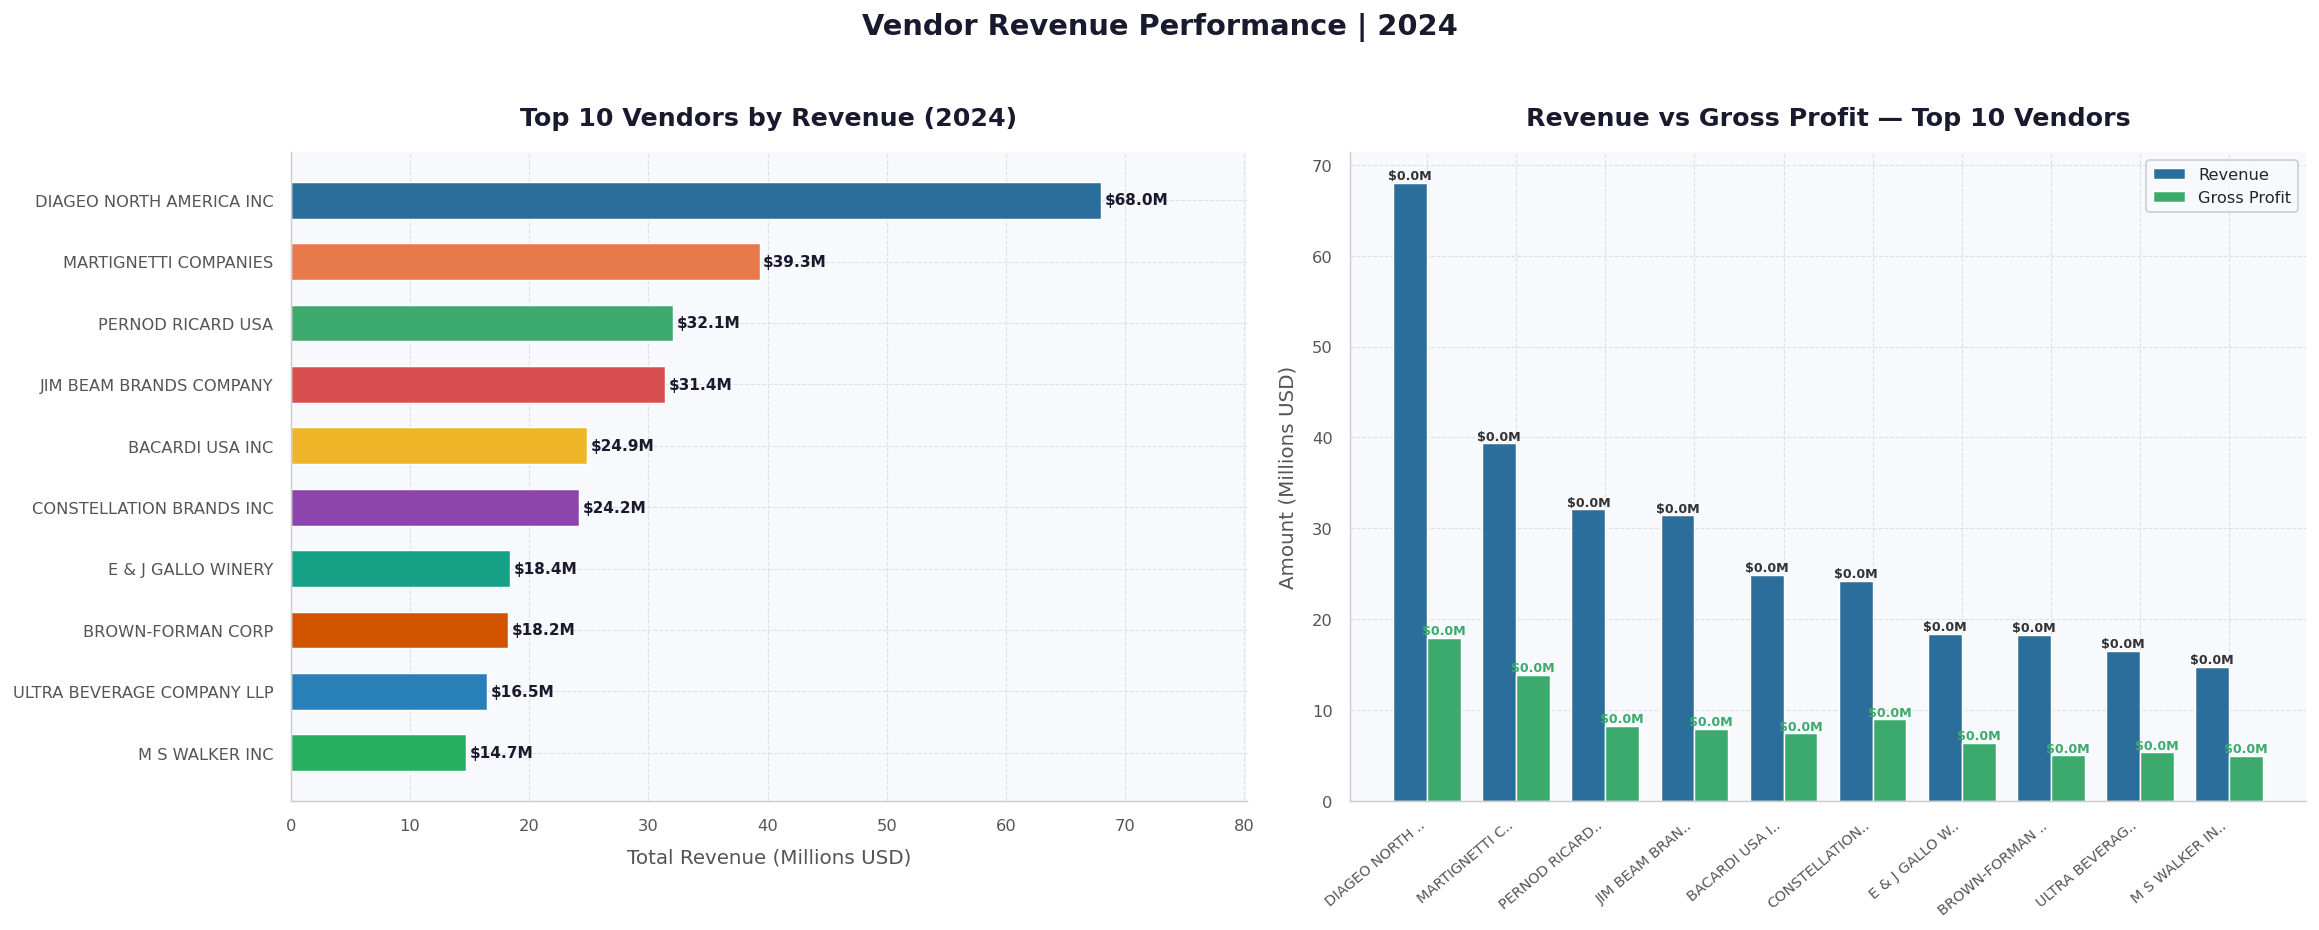

In [9]:
# ─────────────────────────────────────────────
# TOP 10 VENDORS — STYLED VISUALIZATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')

# ── Chart 1: Horizontal Revenue Bar ──
bars = axes[0].barh(
    top_vendors['VendorName'][::-1],
    top_vendors['TotalRevenue'][::-1] / 1_000_000,
    color=PALETTE[:len(top_vendors)][::-1],
    edgecolor='white', linewidth=0.8, height=0.6
)

# Add value labels
for bar, val in zip(bars, top_vendors['TotalRevenue'][::-1] / 1_000_000):
    axes[0].text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
        f'${val:.1f}M', va='center', fontsize=8.5,
        fontweight='bold', color=COLORS['dark']
    )

style_axis(axes[0],
           'Top 10 Vendors by Revenue (2024)',
           xlabel='Total Revenue (Millions USD)',
           legend=False)
axes[0].set_xlim(0, top_vendors['TotalRevenue'].max() / 1_000_000 * 1.18)

# ── Chart 2: Grouped Revenue vs Gross Profit ──
x     = np.arange(len(top_vendors))
width = 0.38

b1 = axes[1].bar(x - width/2,
                  top_vendors['TotalRevenue'] / 1_000_000,
                  width, label='Revenue',
                  color=COLORS['primary'],
                  edgecolor='white', linewidth=0.8)

b2 = axes[1].bar(x + width/2,
                  top_vendors['GrossProfit'] / 1_000_000,
                  width, label='Gross Profit',
                  color=COLORS['success'],
                  edgecolor='white', linewidth=0.8)

add_value_labels(axes[1], b1, fontsize=7)
add_value_labels(axes[1], b2, fontsize=7, color=COLORS['success'])

style_axis(axes[1],
           'Revenue vs Gross Profit — Top 10 Vendors',
           ylabel='Amount (Millions USD)')

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [n[:13] + '..' if len(n) > 13 else n
     for n in top_vendors['VendorName']],
    rotation=40, ha='right', fontsize=8
)

plt.suptitle('Vendor Revenue Performance | 2024',
             fontsize=16, fontweight='bold',
             color=COLORS['dark'], y=1.02)
plt.tight_layout()
plt.show()

#### Key Findings — Top 10 Vendors by Revenue

- **DIAGEO NORTH AMERICA INC** leads with 67.99M dollars in revenue but has the 
  **lowest median margin (27.4%)** among top vendors — growth driven by volume not pricing power
- **CONSTELLATION BRANDS** is the most efficient top vendor at **36.7% median margin** 
  despite ranking 6th by revenue
- **MARTIGNETTI COMPANIES** carries **1,084 unique brands** — the widest portfolio 
  of any vendor — yet maintains a healthy 36.1% margin
- **Freight impact is minimal** — Net Profit is very close to Gross Profit for all 
  top vendors, confirming freight is well controlled
- **BROWN-FORMAN** has the narrowest brand portfolio (111 brands) among top vendors 
  yet ranks 8th by revenue — indicating very high revenue concentration in few SKUs 
  (Jack Daniels being the primary driver)

### 2.2 Pareto Analysis — Which Vendors Drive 80% of Revenue?

The Pareto principle (80/20 rule) suggests that roughly 80% of revenue 
comes from 20% of vendors. We test this hypothesis here.

In [6]:
# ─────────────────────────────────────────────
# PARETO ANALYSIS — VENDOR REVENUE CONTRIBUTION
# ─────────────────────────────────────────────

# Aggregate to vendor level
vendor_pareto = df.groupby('VendorName')\
    .agg(TotalRevenue  = ('TotalSalesDollars',    'sum'),
         GrossProfit   = ('GrossProfit',          'sum'),
         TotalBrands   = ('Brand',                'nunique'))\
    .sort_values('TotalRevenue', ascending=False)\
    .reset_index()

# Calculate cumulative contribution
total_revenue = vendor_pareto['TotalRevenue'].sum()
vendor_pareto['RevenueShare%']      = (vendor_pareto['TotalRevenue'] / total_revenue * 100).round(2)
vendor_pareto['CumulativeShare%']   = vendor_pareto['RevenueShare%'].cumsum().round(2)
vendor_pareto['VendorRank']         = range(1, len(vendor_pareto) + 1)

# Find 80% threshold
vendors_80 = vendor_pareto[vendor_pareto['CumulativeShare%'] <= 80]
print(f"Total Vendors           : {len(vendor_pareto)}")
print(f"Vendors driving 80% rev : {len(vendors_80)}")
print(f"That is                 : {len(vendors_80)/len(vendor_pareto)*100:.1f}% of all vendors")
print(f"\nTop vendors until 80% cumulative revenue:")

# Format for display
display_pareto = vendors_80.copy()
display_pareto['TotalRevenue'] = display_pareto['TotalRevenue']\
    .apply(lambda x: f"${x/1_000_000:.2f}M")
display_pareto['GrossProfit']  = display_pareto['GrossProfit']\
    .apply(lambda x: f"${x/1_000_000:.2f}M")
print(display_pareto[['VendorRank', 'VendorName', 'TotalRevenue',
                       'GrossProfit', 'RevenueShare%',
                       'CumulativeShare%', 'TotalBrands']].to_string(index=False))

Total Vendors           : 126
Vendors driving 80% rev : 17
That is                 : 13.5% of all vendors

Top vendors until 80% cumulative revenue:
 VendorRank                 VendorName TotalRevenue GrossProfit  RevenueShare%  CumulativeShare%  TotalBrands
          1   DIAGEO NORTH AMERICA INC      $68.74M     $17.78M          15.22             15.22          395
          2      MARTIGNETTI COMPANIES      $40.96M     $13.14M           9.07             24.29         1363
          3          PERNOD RICARD USA      $32.28M      $8.16M           7.15             31.44          245
          4    JIM BEAM BRANDS COMPANY      $31.90M      $7.70M           7.06             38.50          367
          5            BACARDI USA INC      $25.01M      $7.38M           5.54             44.04          164
          6   CONSTELLATION BRANDS INC      $24.47M      $8.90M           5.42             49.46          453
          7         E & J GALLO WINERY      $18.55M      $6.27M           4.11   

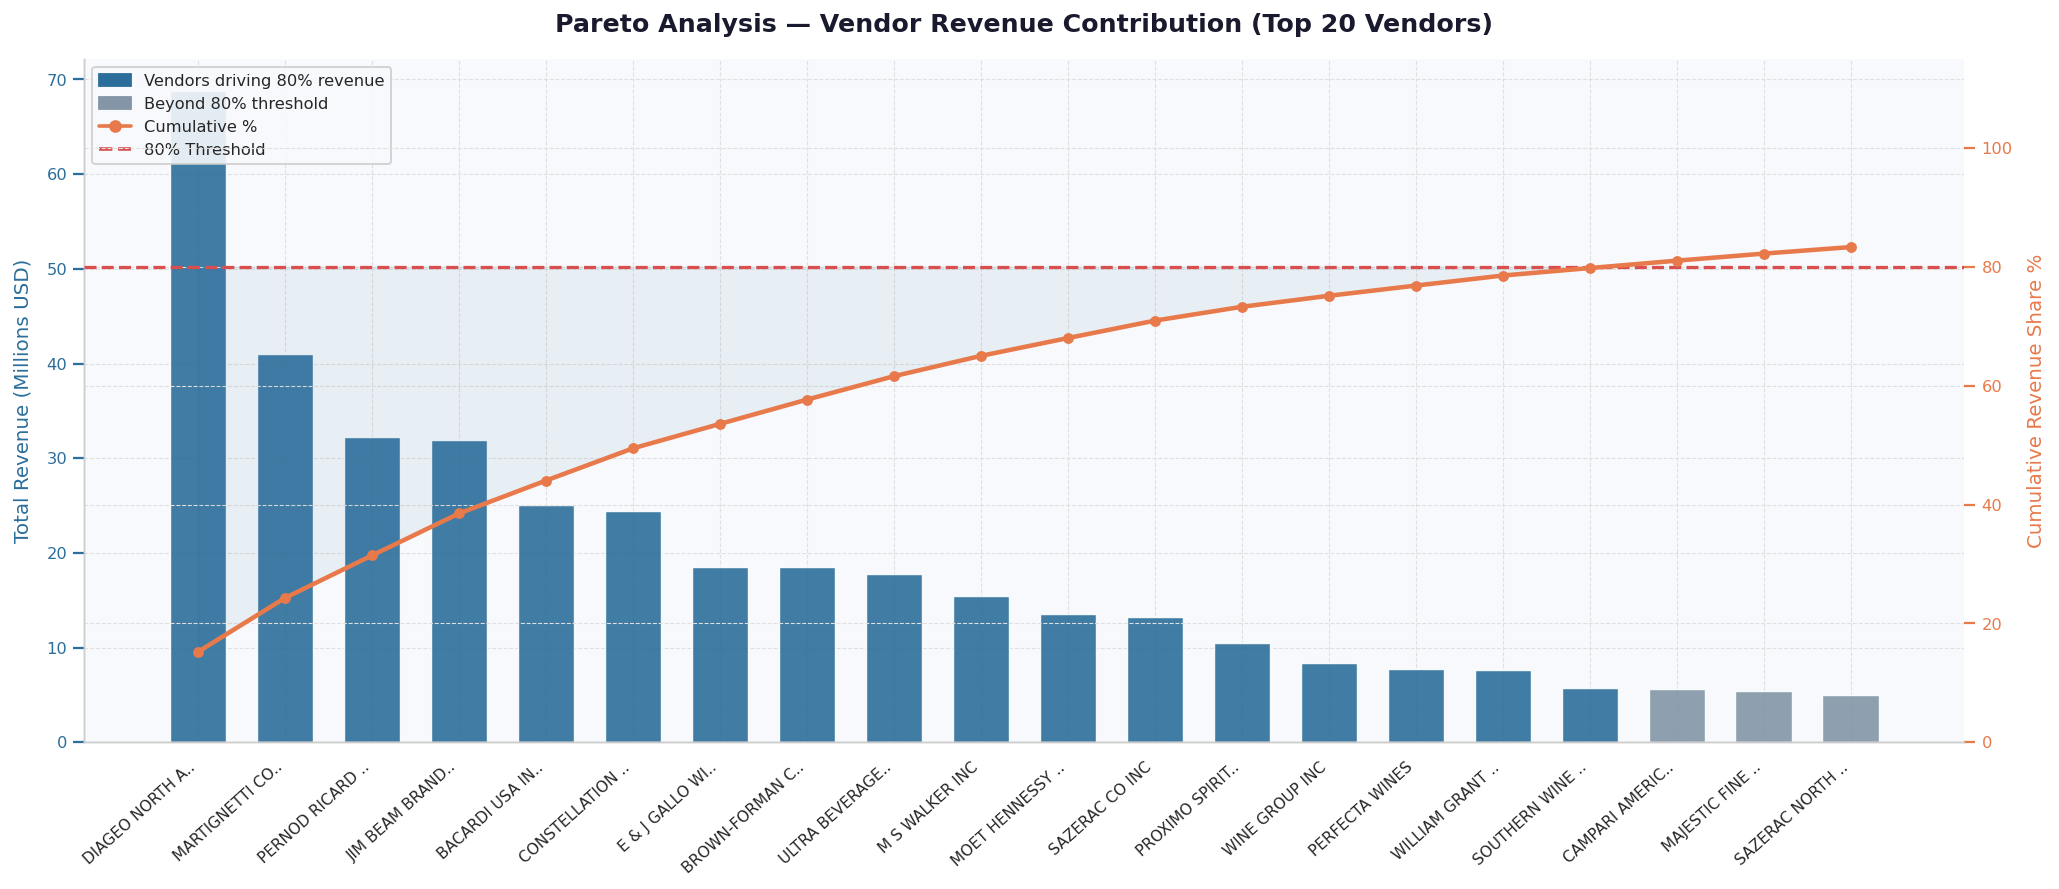

In [11]:
# ─────────────────────────────────────────────
# PARETO ANALYSIS — STYLED VISUALIZATION
# ─────────────────────────────────────────────

top20 = vendor_pareto.head(20)

fig, ax1 = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')

# Color bars — highlight vendors below 80% threshold
bar_colors = [
    COLORS['primary'] if c <= 80 else COLORS['muted']
    for c in top20['CumulativeShare%']
]

bars = ax1.bar(
    range(len(top20)),
    top20['TotalRevenue'] / 1_000_000,
    color=bar_colors, edgecolor='white',
    linewidth=0.8, width=0.65, alpha=0.9
)

ax1.set_ylabel('Total Revenue (Millions USD)',
               fontsize=11, color=COLORS['primary'], labelpad=8)
ax1.set_xticks(range(len(top20)))
ax1.set_xticklabels(
    [n[:14] + '..' if len(n) > 14 else n
     for n in top20['VendorName']],
    rotation=42, ha='right', fontsize=8.5
)
ax1.tick_params(axis='y', colors=COLORS['primary'])

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(range(len(top20)),
         top20['CumulativeShare%'],
         color=COLORS['secondary'], marker='o',
         linewidth=2.5, markersize=5,
         label='Cumulative Revenue %', zorder=5)

# 80% threshold line
ax2.axhline(80, color=COLORS['danger'],
            linestyle='--', linewidth=1.8,
            label='80% Threshold', zorder=4)

# Shade the 80% area
ax2.fill_between(range(len(top20)),
                 top20['CumulativeShare%'],
                 80,
                 where=[c <= 80 for c in top20['CumulativeShare%']],
                 alpha=0.08, color=COLORS['primary'])

ax2.set_ylabel('Cumulative Revenue Share %',
               fontsize=11, color=COLORS['secondary'], labelpad=8)
ax2.set_ylim(0, 115)
ax2.tick_params(axis='y', colors=COLORS['secondary'])

# Legend
legend_elements = [
    mpatches.Patch(color=COLORS['primary'], label='Vendors driving 80% revenue'),
    mpatches.Patch(color=COLORS['muted'],   label='Beyond 80% threshold'),
    plt.Line2D([0], [0], color=COLORS['secondary'],
               marker='o', linewidth=2, label='Cumulative %'),
    plt.Line2D([0], [0], color=COLORS['danger'],
               linestyle='--', linewidth=2, label='80% Threshold')
]
ax1.legend(handles=legend_elements, loc='upper left',
           framealpha=0.9, fontsize=9)

ax1.set_title('Pareto Analysis — Vendor Revenue Contribution (Top 20 Vendors)',
              fontsize=14, fontweight='bold',
              color=COLORS['dark'], pad=15)
ax1.set_facecolor('#F7F9FC')

plt.tight_layout()
plt.show()

#### Key Findings — Pareto Analysis

- **Just 17 out of 126 vendors (13.5%) drive 80% of total revenue** — 
  more concentrated than the classic 80/20 rule
- **DIAGEO alone contributes 15.22%** of all revenue — single vendor dependency risk
- **Top 4 vendors combined (DIAGEO, MARTIGNETTI, PERNOD, JIM BEAM) 
  account for 38.5%** of total revenue
- **MARTIGNETTI carries 1,363 brands** — the widest portfolio of any vendor 
  yet ranks 2nd by revenue, suggesting strong demand across their range
- **PERFECTA WINES (rank 15) has 769 brands** but only 1.72% revenue share — 
  large portfolio but low revenue per brand
- **Business implication:** The remaining 109 vendors share only 20% of revenue. 
  Procurement strategy should prioritise relationship strength with the top 17.

## 3. Profitability Analysis

### 3.1 Top 10 Vendors by Profit Margin
Revenue tells us who sells the most. Margin tells us who sells the smartest.

In [13]:
# ─────────────────────────────────────────────
# TOP 10 VENDORS BY PROFIT MARGIN
# Minimum revenue threshold applied to exclude
# vendors with very low sales inflating margins
# ─────────────────────────────────────────────

# Set minimum revenue threshold — vendors with at least $1M in sales
min_revenue_threshold = 1_000_000

vendor_margins = df[df['IsUnderperforming'] == False]\
    .groupby('VendorName')\
    .agg(
        TotalRevenue  = ('TotalSalesDollars',    'sum'),
        GrossProfit   = ('GrossProfit',          'sum'),
        NetProfit     = ('NetProfit',            'sum'),
        MedianMargin  = ('ProfitMargin%',        'median'),
        TotalBrands   = ('Brand',                'nunique')
    )\
    .reset_index()

# Filter by minimum revenue
vendor_margins = vendor_margins[
    vendor_margins['TotalRevenue'] >= min_revenue_threshold
]

# Top 10 by median margin
top_margins = vendor_margins\
    .sort_values('MedianMargin', ascending=False)\
    .head(10)\
    .reset_index(drop=True)

# Format for display
display_margins = top_margins.copy()
for col in ['TotalRevenue', 'GrossProfit', 'NetProfit']:
    display_margins[col] = display_margins[col]\
        .apply(lambda x: f"${x/1_000_000:.2f}M")
display_margins['MedianMargin'] = display_margins['MedianMargin']\
    .apply(lambda x: f"{x:.1f}%")

print(f"Vendors with revenue above $1M threshold: {len(vendor_margins)}")
print(f"\nTop 10 Vendors by Median Profit Margin:")
print(display_margins[['VendorName', 'TotalRevenue', 'GrossProfit',
                        'MedianMargin', 'TotalBrands']].to_string(index=False))

Vendors with revenue above $1M threshold: 41

Top 10 Vendors by Median Profit Margin:
                 VendorName TotalRevenue GrossProfit MedianMargin  TotalBrands
        KOBRAND CORPORATION       $2.79M      $1.05M        42.3%          128
      TREASURY WINE ESTATES       $4.69M      $1.80M        39.7%           87
 SOUTHERN WINE & SPIRITS NE       $5.54M      $2.11M        38.9%          256
   CONSTELLATION BRANDS INC      $24.22M      $8.95M        36.7%          381
        VINEYARD BRANDS INC       $1.83M      $0.65M        36.6%           67
  STE MICHELLE WINE ESTATES       $4.89M      $1.82M        36.1%          125
      MARTIGNETTI COMPANIES      $39.33M     $13.83M        36.1%         1084
DIAGEO CHATEAU ESTATE WINES       $2.12M      $0.84M        36.0%           77
        BANFI PRODUCTS CORP       $2.63M      $1.02M        35.6%          121
             PERFECTA WINES       $7.17M      $2.55M        35.2%          575


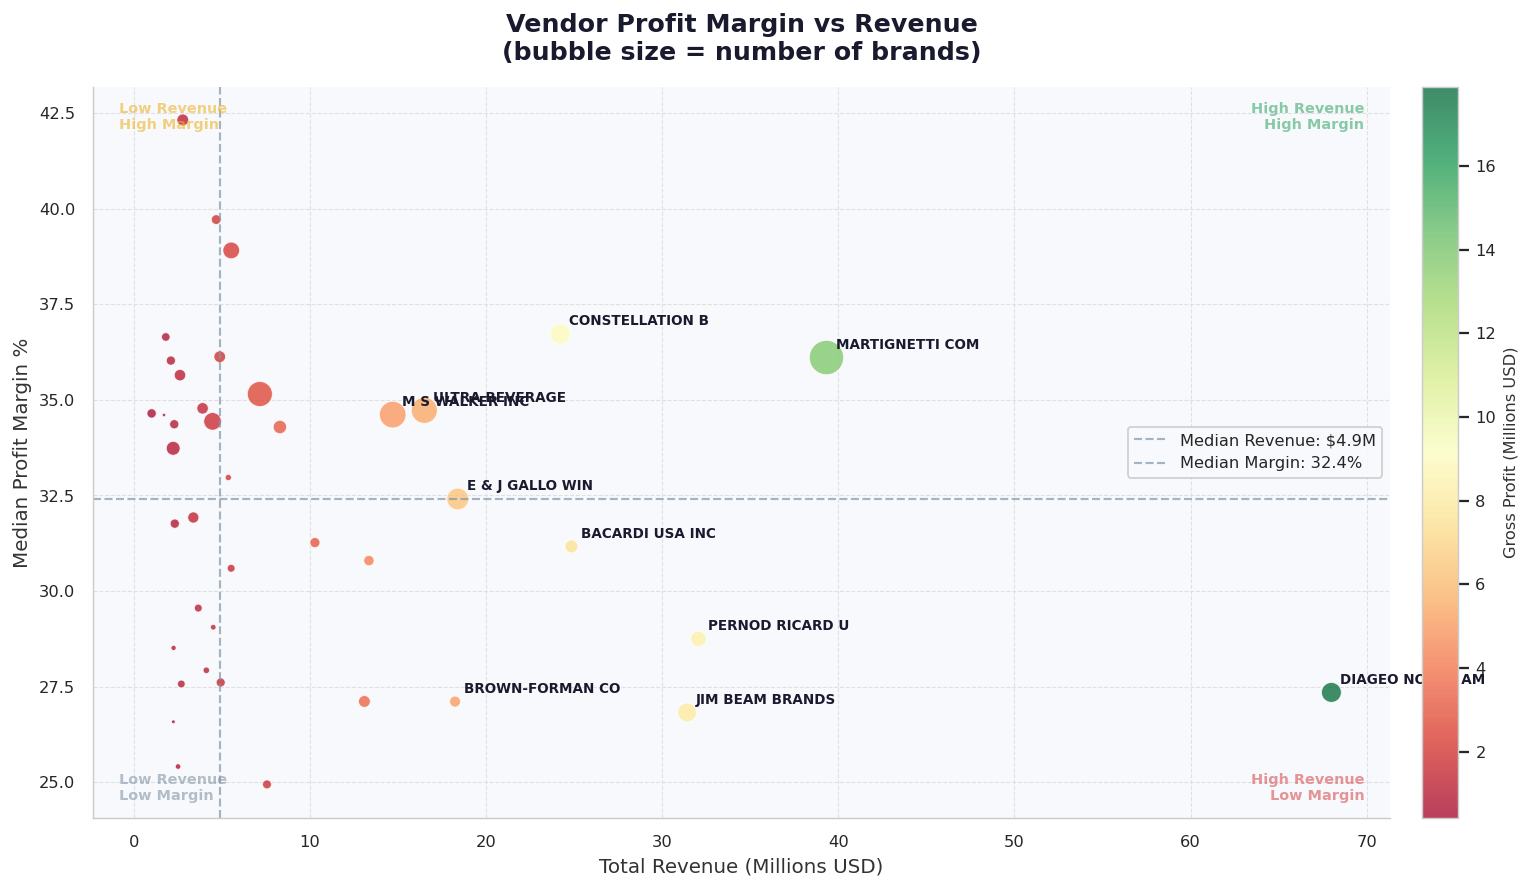

In [14]:
# ─────────────────────────────────────────────
# MARGIN vs REVENUE SCATTER PLOT
# Identifies vendors that are both high revenue
# AND high margin — the sweet spot
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 7))

# Plot all vendors
scatter = ax.scatter(
    vendor_margins['TotalRevenue'] / 1_000_000,
    vendor_margins['MedianMargin'],
    c=vendor_margins['GrossProfit'] / 1_000_000,
    cmap='RdYlGn', alpha=0.75,
    s=vendor_margins['TotalBrands'] / 3,
    edgecolors='white', linewidth=0.5
)

# Reference lines — median revenue and median margin
median_rev    = vendor_margins['TotalRevenue'].median() / 1_000_000
median_margin = vendor_margins['MedianMargin'].median()

ax.axvline(median_rev, color=COLORS['muted'],
           linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Median Revenue: ${median_rev:.1f}M')
ax.axhline(median_margin, color=COLORS['muted'],
           linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Median Margin: {median_margin:.1f}%')

# Label top vendors
for _, row in vendor_margins.nlargest(10, 'TotalRevenue').iterrows():
    ax.annotate(
        row['VendorName'][:15],
        xy=(row['TotalRevenue'] / 1_000_000, row['MedianMargin']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=7.5, color=COLORS['dark'],
        fontweight='bold'
    )

# Quadrant labels
ax.text(0.98, 0.98, 'High Revenue\nHigh Margin',
        transform=ax.transAxes, fontsize=8,
        color=COLORS['success'], fontweight='bold',
        ha='right', va='top', alpha=0.6)
ax.text(0.02, 0.98, 'Low Revenue\nHigh Margin',
        transform=ax.transAxes, fontsize=8,
        color=COLORS['warning'], fontweight='bold',
        ha='left', va='top', alpha=0.6)
ax.text(0.98, 0.02, 'High Revenue\nLow Margin',
        transform=ax.transAxes, fontsize=8,
        color=COLORS['danger'], fontweight='bold',
        ha='right', va='bottom', alpha=0.6)
ax.text(0.02, 0.02, 'Low Revenue\nLow Margin',
        transform=ax.transAxes, fontsize=8,
        color=COLORS['muted'], fontweight='bold',
        ha='left', va='bottom', alpha=0.6)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Gross Profit (Millions USD)', fontsize=9)

ax.set_title('Vendor Profit Margin vs Revenue\n'
             '(bubble size = number of brands)',
             fontsize=14, fontweight='bold', color=COLORS['dark'])
ax.set_xlabel('Total Revenue (Millions USD)')
ax.set_ylabel('Median Profit Margin %')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

#### Key Findings — Profitability Analysis

- **Wine-focused vendors dominate the top margin list** — KOBRAND (42.3%), 
  TREASURY WINE ESTATES (39.7%), STE MICHELLE (36.1%) all primarily deal in wine, 
  suggesting wine carries structurally higher margins than spirits in this business
- **CONSTELLATION BRANDS** is the standout performer — 4th highest revenue 
  (24.22M dollars) AND 4th highest margin (36.7%) — the best combination of 
  scale and efficiency among all vendors
- **MARTIGNETTI** appears in both top revenue AND top margin lists — 
  confirming they are the most well-rounded vendor in the portfolio
- **KOBRAND CORPORATION** has the highest margin at 42.3%** but only 2.79M 
  in revenue — high margin niche player, not a volume vendor
- **Scatter plot quadrant analysis:**
  - Top-right (High Revenue + High Margin): CONSTELLATION, MARTIGNETTI — 
    ideal vendors to prioritise and grow
  - Top-left (Low Revenue + High Margin): KOBRAND, TREASURY — 
    potential to grow volume with these vendors
  - Bottom-right (High Revenue + Low Margin): DIAGEO, JIM BEAM — 
    volume dependent, margin improvement needed

### 3.2 Bottom 10 Vendors by Profitability
Identifying underperforming vendors is as important as identifying top performers.
These vendors represent either pricing problems, demand issues, or poor product mix.

In [16]:
# ─────────────────────────────────────────────
# BOTTOM 10 VENDORS BY NET PROFIT
# Using all records including underperforming
# to get the true picture of loss-making vendors
# ─────────────────────────────────────────────

bottom_vendors = df.groupby('VendorName')\
    .agg(
        TotalRevenue        = ('TotalSalesDollars',    'sum'),
        TotalPurchases      = ('TotalPurchaseDollars', 'sum'),
        GrossProfit         = ('GrossProfit',          'sum'),
        NetProfit           = ('NetProfit',            'sum'),
        MedianMargin        = ('ProfitMargin%',        'median'),
        UnderperformingSKUs = ('IsUnderperforming',    'sum'),
        TotalBrands         = ('Brand',                'nunique')
    )\
    .reset_index()

# Only vendors with meaningful revenue
bottom_vendors = bottom_vendors[
    bottom_vendors['TotalRevenue'] >= 1_000_000
]

bottom10 = bottom_vendors\
    .sort_values('NetProfit', ascending=True)\
    .head(10)\
    .reset_index(drop=True)

# Format for display
display_bottom = bottom10.copy()
for col in ['TotalRevenue', 'GrossProfit', 'NetProfit']:
    display_bottom[col] = display_bottom[col]\
        .apply(lambda x: f"${x/1_000_000:.2f}M")
display_bottom['MedianMargin'] = display_bottom['MedianMargin']\
    .apply(lambda x: f"{x:.1f}%")

print("Bottom 10 Vendors by Net Profit (Revenue > $1M):")
print(display_bottom[['VendorName', 'TotalRevenue', 'GrossProfit',
                       'NetProfit', 'MedianMargin',
                       'UnderperformingSKUs',
                       'TotalBrands']].to_string(index=False))

Bottom 10 Vendors by Net Profit (Revenue > $1M):
                 VendorName TotalRevenue GrossProfit NetProfit MedianMargin  UnderperformingSKUs  TotalBrands
   FREDERICK WILDMAN & SONS       $1.13M      $0.37M    $0.37M        25.4%                   40          120
  SIDNEY FRANK IMPORTING CO       $2.26M      $0.54M    $0.53M        26.6%                    0           13
DISARONNO INTERNATIONAL LLC       $1.73M      $0.58M    $0.58M        34.6%                    0           11
        CASTLE BRANDS CORP.       $2.31M      $0.63M    $0.62M        27.0%                    2           26
         EDRINGTON AMERICAS       $2.52M      $0.64M    $0.63M        24.9%                    1           29
        VINEYARD BRANDS INC       $1.84M      $0.65M    $0.64M        36.5%                    3           70
                    MHW LTD       $2.59M      $0.70M    $0.69M        29.7%                    9           87
                  LUXCO INC       $2.83M      $0.77M    $0.76M        2

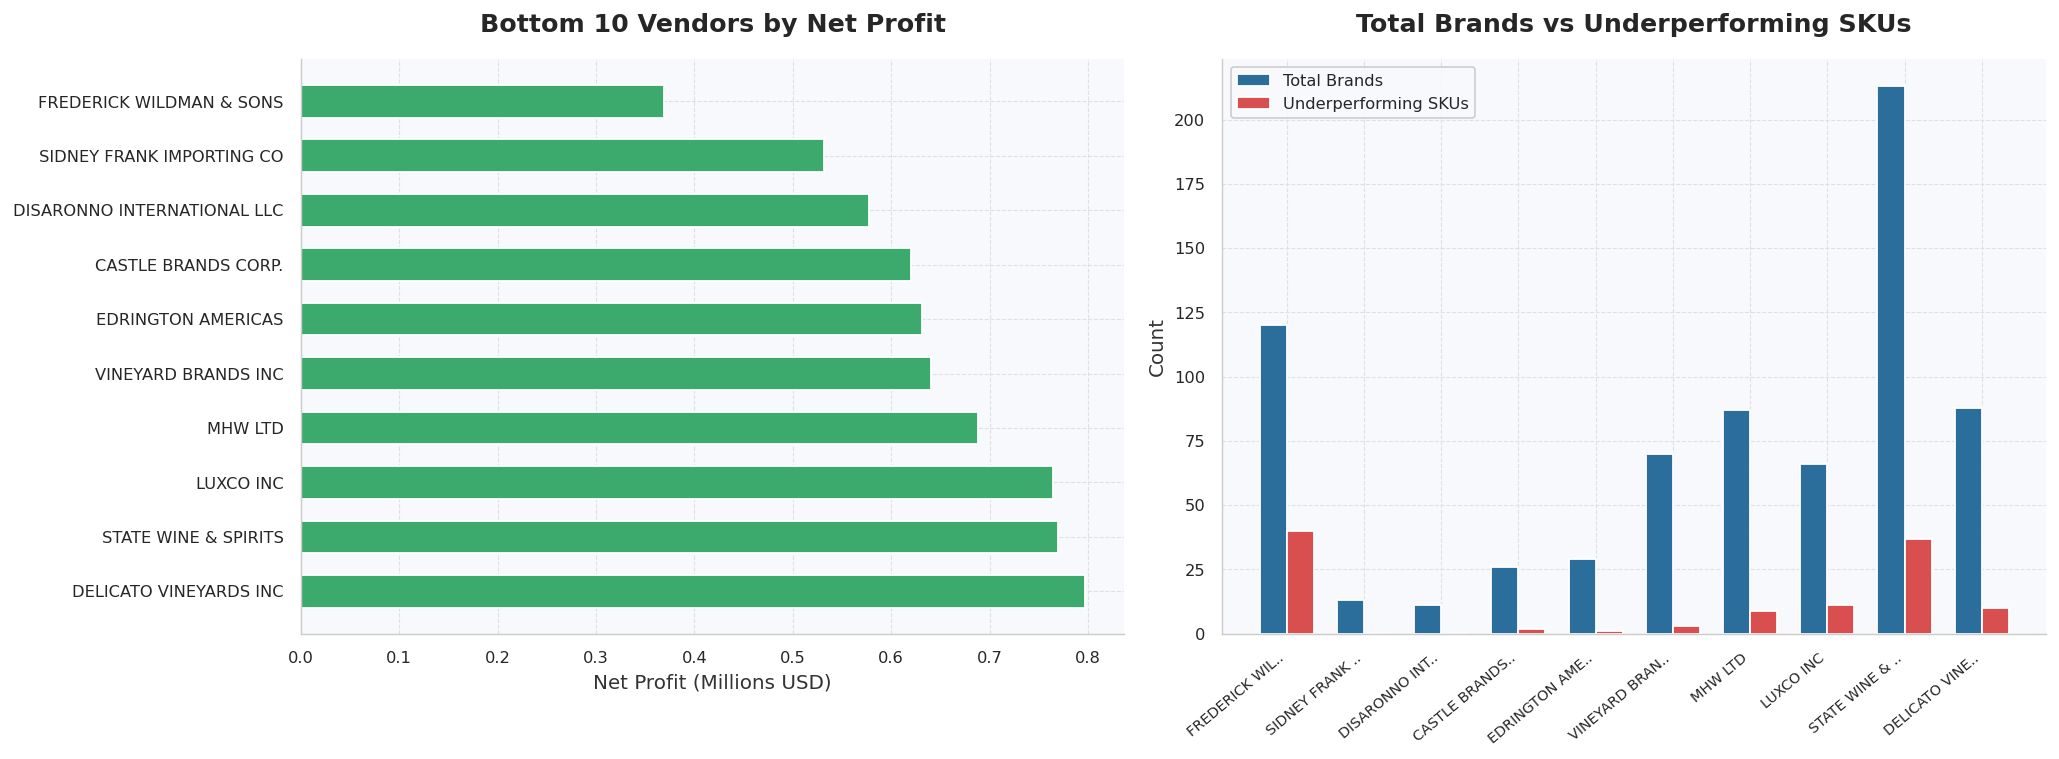

In [18]:
# ─────────────────────────────────────────────
# BOTTOM VENDORS — VISUALIZATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Net Profit bar (negative = red, positive = green) ──
colors = [COLORS['danger'] if x < 0 else COLORS['success']
          for x in bottom10['NetProfit']]

axes[0].barh(
    bottom10['VendorName'][::-1],
    bottom10['NetProfit'][::-1] / 1_000_000,
    color=colors[::-1], edgecolor='white', height=0.6
)
axes[0].axvline(0, color=COLORS['dark'], linewidth=1)
axes[0].set_title('Bottom 10 Vendors by Net Profit')
axes[0].set_xlabel('Net Profit (Millions USD)')

# ── Chart 2: Underperforming SKUs vs Total Brands ──
x     = np.arange(len(bottom10))
width = 0.35

axes[1].bar(x - width/2,
            bottom10['TotalBrands'],
            width, label='Total Brands',
            color=COLORS['primary'], edgecolor='white')
axes[1].bar(x + width/2,
            bottom10['UnderperformingSKUs'],
            width, label='Underperforming SKUs',
            color=COLORS['danger'], edgecolor='white')

axes[1].set_title('Total Brands vs Underperforming SKUs')
axes[1].set_ylabel('Count')
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [n[:13] + '..' if len(n) > 13 else n
     for n in bottom10['VendorName']],
    rotation=40, ha='right', fontsize=8
)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Key Findings — Bottom 10 Vendors by Net Profit

- **All bottom 10 vendors are actually profitable** — these are the lowest 
  profit contributors above the 1M dollar revenue threshold, not loss-makers
- **FREDERICK WILDMAN & SONS** is the most concerning — 40 out of 120 brands 
  (33%) are underperforming, the highest underperforming SKU ratio of any vendor
- **SIDNEY FRANK and DISARONNO** have zero underperforming SKUs despite low 
  profits — their issue is purely low volume, not bad products
- **EDRINGTON AMERICAS** carries premium products (Macallan, Highland Park) 
  with only 29 brands but 24.9% median margin — low profit due to low volume 
  not poor margins
- **Recommendation:** Vendors like FREDERICK WILDMAN need SKU rationalisation — 
  reducing their underperforming product range could improve overall margins

## 4. Inventory Efficiency — Stock Turnover Analysis

Stock Turnover measures how efficiently inventory is being converted to sales.
A ratio of 1.0 means every unit purchased was sold.
Above 1.0 means selling from older stock.
Below 1.0 means purchased more than was sold — potential overstock risk.

In [19]:
# ─────────────────────────────────────────────
# STOCK TURNOVER — VENDOR LEVEL ANALYSIS
# ─────────────────────────────────────────────

turnover = df.groupby('VendorName')\
    .agg(
        TotalRevenue          = ('TotalSalesDollars',    'sum'),
        TotalPurchaseQty      = ('TotalPurchaseQuantity','sum'),
        TotalSalesQty         = ('TotalSalesQuantity',   'sum'),
        MedianTurnover        = ('StockTurnover',        'median'),
        UnderperformingSKUs   = ('IsUnderperforming',    'sum'),
        TotalBrands           = ('Brand',                'nunique')
    )\
    .reset_index()

# Filter meaningful vendors
turnover = turnover[turnover['TotalRevenue'] >= 1_000_000]
turnover['OverallTurnover'] = (
    turnover['TotalSalesQty'] / turnover['TotalPurchaseQty']
).round(3)

print("=== Stock Turnover Summary ===\n")
print(f"Vendors with Turnover > 1.0 (selling old stock)  : "
      f"{(turnover['OverallTurnover'] > 1).sum()}")
print(f"Vendors with Turnover = 1.0 (perfectly balanced) : "
      f"{(turnover['OverallTurnover'] == 1).sum()}")
print(f"Vendors with Turnover < 1.0 (overstock risk)     : "
      f"{(turnover['OverallTurnover'] < 1).sum()}")

print(f"\nTop 10 vendors by Stock Turnover:")
print(turnover.nlargest(10, 'OverallTurnover')[
    ['VendorName', 'TotalRevenue', 'TotalPurchaseQty',
     'TotalSalesQty', 'OverallTurnover']
].to_string(index=False))

print(f"\nBottom 10 vendors by Stock Turnover (overstock risk):")
print(turnover.nsmallest(10, 'OverallTurnover')[
    ['VendorName', 'TotalRevenue', 'TotalPurchaseQty',
     'TotalSalesQty', 'OverallTurnover']
].to_string(index=False))

=== Stock Turnover Summary ===

Vendors with Turnover > 1.0 (selling old stock)  : 7
Vendors with Turnover = 1.0 (perfectly balanced) : 0
Vendors with Turnover < 1.0 (overstock risk)     : 34

Top 10 vendors by Stock Turnover:
                 VendorName  TotalRevenue  TotalPurchaseQty  TotalSalesQty  OverallTurnover
       STATE WINE & SPIRITS  2.293833e+06            153045       157402.0            1.028
            BACARDI USA INC  2.500537e+07           1427005      1457011.0            1.021
DIAGEO CHATEAU ESTATE WINES  2.182527e+06            187829       190742.0            1.016
                  LUXCO INC  2.826288e+06            283260       286953.0            1.013
  SIDNEY FRANK IMPORTING CO  2.256371e+06            186464       188625.0            1.012
        KOBRAND CORPORATION  2.829620e+06            160936       161687.0            1.005
DISARONNO INTERNATIONAL LLC  1.725259e+06            103095       103387.0            1.003
  STE MICHELLE WINE ESTATES  4.899405

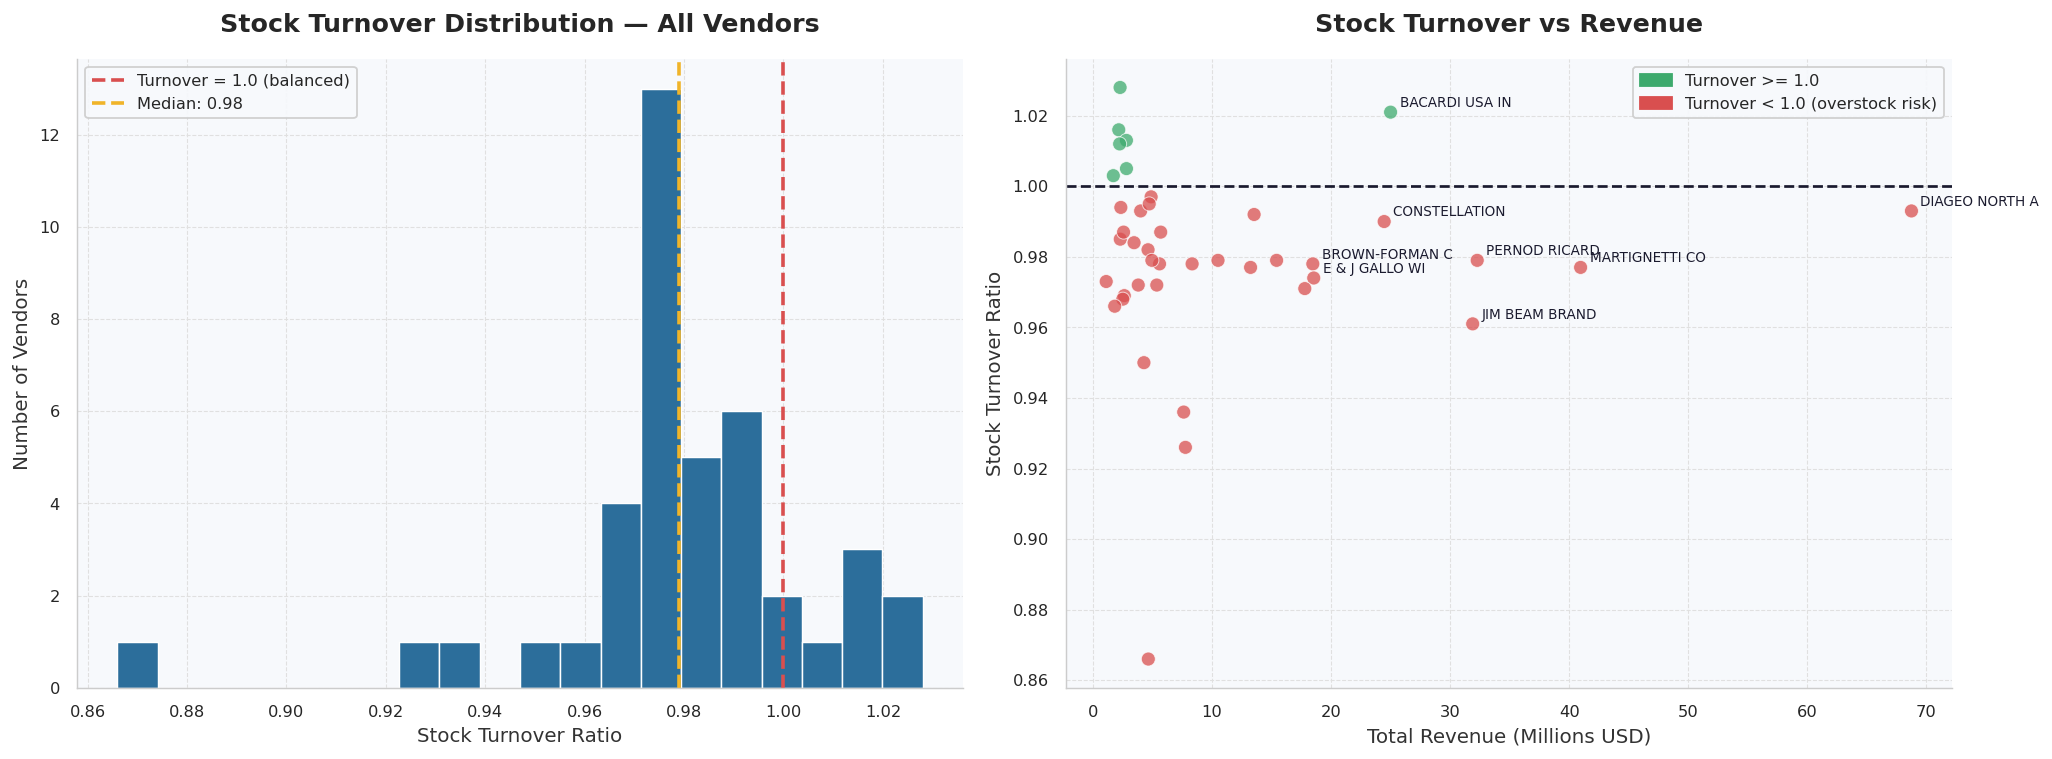

In [20]:
# ─────────────────────────────────────────────
# STOCK TURNOVER — VISUALIZATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Turnover distribution ──
axes[0].hist(
    turnover['OverallTurnover'],
    bins=20, color=COLORS['primary'],
    edgecolor='white', linewidth=0.8
)
axes[0].axvline(1.0, color=COLORS['danger'],
                linestyle='--', linewidth=2,
                label='Turnover = 1.0 (balanced)')
axes[0].axvline(turnover['OverallTurnover'].median(),
                color=COLORS['warning'],
                linestyle='--', linewidth=2,
                label=f"Median: {turnover['OverallTurnover'].median():.2f}")
axes[0].set_title('Stock Turnover Distribution — All Vendors')
axes[0].set_xlabel('Stock Turnover Ratio')
axes[0].set_ylabel('Number of Vendors')
axes[0].legend()

# ── Chart 2: Turnover vs Revenue scatter ──
colors = [COLORS['success'] if x >= 1 else COLORS['danger']
          for x in turnover['OverallTurnover']]

axes[1].scatter(
    turnover['TotalRevenue'] / 1_000_000,
    turnover['OverallTurnover'],
    c=colors, alpha=0.75, s=60,
    edgecolors='white', linewidth=0.5
)
axes[1].axhline(1.0, color=COLORS['dark'],
                linestyle='--', linewidth=1.5,
                label='Turnover = 1.0')

# Label top vendors
for _, row in turnover.nlargest(8, 'TotalRevenue').iterrows():
    axes[1].annotate(
        row['VendorName'][:14],
        xy=(row['TotalRevenue'] / 1_000_000, row['OverallTurnover']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=7.5, color=COLORS['dark']
    )

axes[1].set_title('Stock Turnover vs Revenue')
axes[1].set_xlabel('Total Revenue (Millions USD)')
axes[1].set_ylabel('Stock Turnover Ratio')
axes[1].legend()

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color=COLORS['success'], label='Turnover >= 1.0'),
    Patch(color=COLORS['danger'],  label='Turnover < 1.0 (overstock risk)')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

#### Key Findings — Stock Turnover Analysis

- **83% of vendors (34 out of 41) have turnover below 1.0** — purchases 
  exceeded sales across most of the vendor portfolio in 2024
- This is consistent with our EDA finding that total inventory value 
  grew by 11.6 million dollars during the year
- **STOLI GROUP is the most overstocked vendor** at 0.866 turnover — 
  only 86.6% of purchased units were sold, likely impacted by consumer 
  sentiment around Russian-origin brands in 2024
- **JIM BEAM has the largest absolute overstock** — 107,000 units 
  purchased but not sold, representing significant capital tied up in inventory
- **BACARDI is the most efficient large vendor** at 1.021 — selling 
  slightly more than purchased by drawing down existing stock
- **Only 7 vendors have turnover above 1.0** — these vendors are drawing 
  down existing inventory, indicating strong demand relative to purchasing
- **Recommendation:** Review purchasing volumes for STOLI, PERFECTA and 
  WILLIAM GRANT — their turnover ratios suggest systematic over-purchasing

## 5. Freight Cost Impact Analysis

Freight costs directly reduce net profitability. Here we examine which 
vendors have the highest freight burden relative to their revenue and profit.

In [21]:
# ─────────────────────────────────────────────
# FREIGHT COST IMPACT — VENDOR LEVEL
# ─────────────────────────────────────────────

freight = df.groupby('VendorName')\
    .agg(
        TotalRevenue        = ('TotalSalesDollars',    'sum'),
        GrossProfit         = ('GrossProfit',          'sum'),
        NetProfit           = ('NetProfit',            'sum'),
        TotalFreight        = ('AllocatedFreightCost', 'sum'),
        TotalBrands         = ('Brand',                'nunique')
    )\
    .reset_index()

freight = freight[freight['TotalRevenue'] >= 1_000_000]

# Freight as % of revenue and % of gross profit
freight['FreightToRevenue%'] = (
    freight['TotalFreight'] / freight['TotalRevenue'] * 100
).round(3)

freight['FreightToProfit%'] = (
    freight['TotalFreight'] / freight['GrossProfit'] * 100
).round(3)

print("=== Freight Cost Impact ===\n")
print(f"Total Allocated Freight (vendors > $1M revenue): "
      f"${freight['TotalFreight'].sum():,.2f}")
print(f"As % of Total Revenue: "
      f"{freight['TotalFreight'].sum()/freight['TotalRevenue'].sum()*100:.3f}%")

print(f"\nTop 10 Vendors — Highest Freight as % of Revenue:")
print(freight.nlargest(10, 'FreightToRevenue%')[
    ['VendorName', 'TotalRevenue', 'TotalFreight',
     'FreightToRevenue%', 'FreightToProfit%']
].apply(lambda col: col.map(
    lambda x: f"${x/1_000_000:.2f}M" if isinstance(x, float)
    and x > 1000 else f"{x:.3f}%" if isinstance(x, float)
    else x
) if col.name not in ['VendorName'] else col).to_string(index=False))

=== Freight Cost Impact ===

Total Allocated Freight (vendors > $1M revenue): $1,594,991.62
As % of Total Revenue: 0.362%

Top 10 Vendors — Highest Freight as % of Revenue:
                VendorName TotalRevenue TotalFreight FreightToRevenue% FreightToProfit%
     STOLI GROUP,(USA) LLC       $4.66M       $0.02M            0.397%           1.844%
  WILLIAM GRANT & SONS INC       $7.64M       $0.03M            0.396%           1.806%
    REMY COINTREAU USA INC       $4.29M       $0.02M            0.395%           1.806%
   JIM BEAM BRANDS COMPANY      $31.90M       $0.12M            0.388%           1.610%
        EDRINGTON AMERICAS       $2.52M       $0.01M            0.383%           1.506%
         PERNOD RICARD USA      $32.28M       $0.12M            0.383%           1.518%
            SAZERAC CO INC      $13.25M       $0.05M            0.380%           1.509%
 SIDNEY FRANK IMPORTING CO       $2.26M       $0.01M            0.379%           1.582%
ULTRA BEVERAGE COMPANY LLP      $17

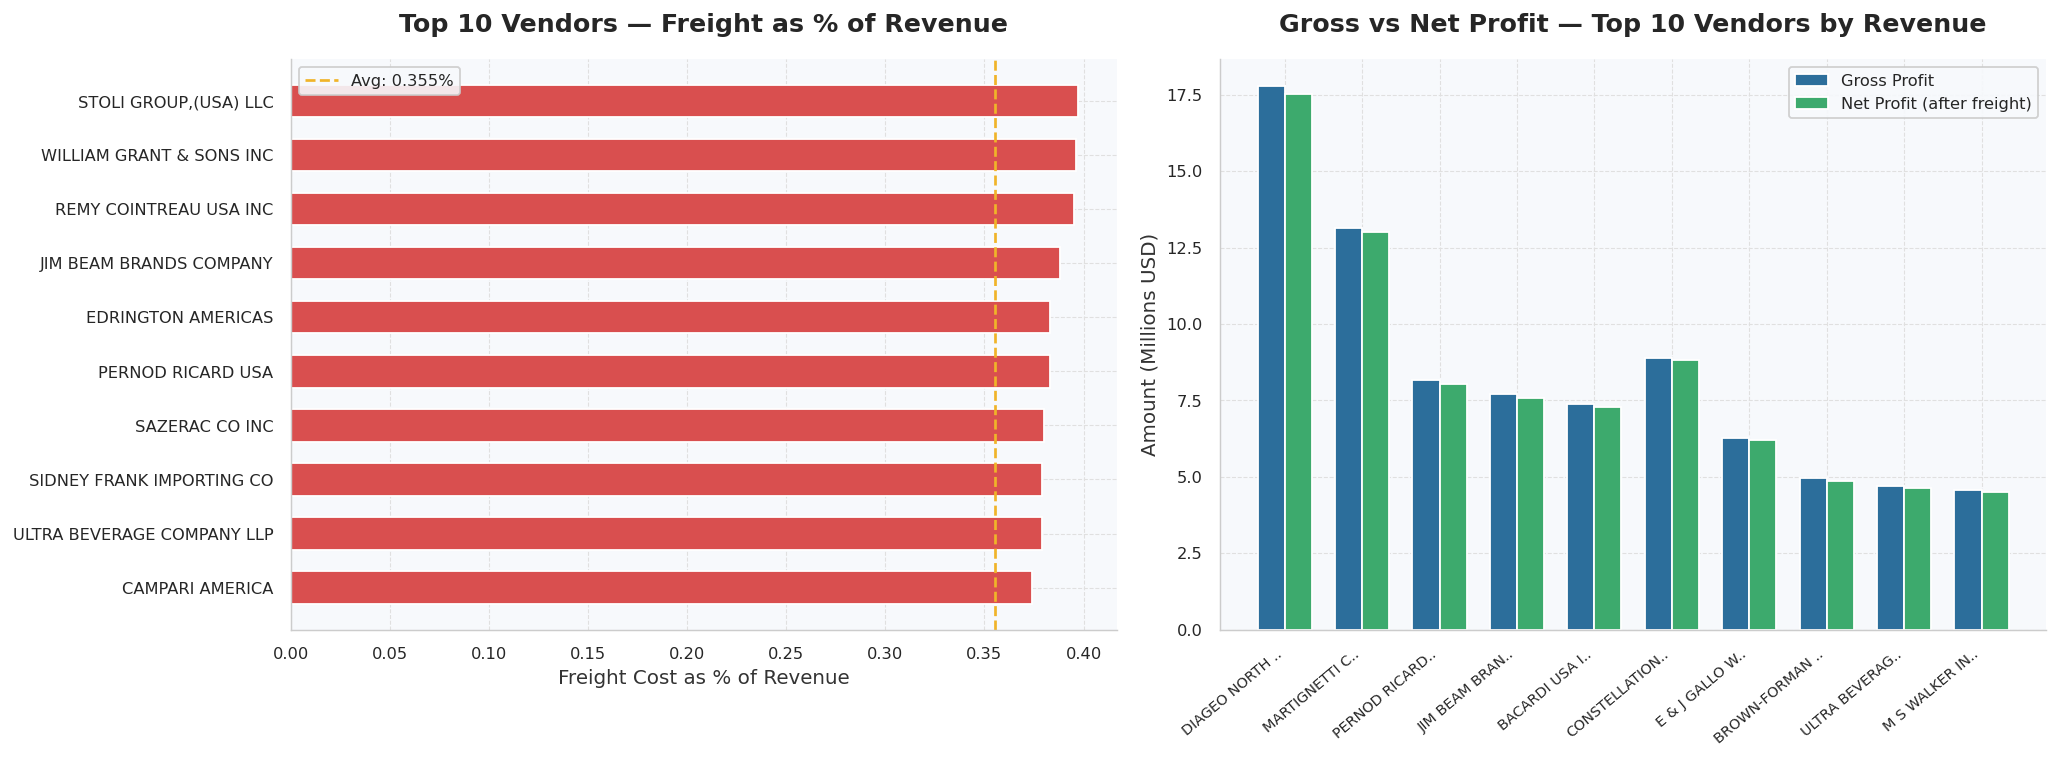

In [22]:
# ─────────────────────────────────────────────
# FREIGHT COST — VISUALIZATION
# ─────────────────────────────────────────────

top_freight = freight.nlargest(10, 'FreightToRevenue%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Freight as % of Revenue ──
colors = [COLORS['danger'] if x > freight['FreightToRevenue%'].mean()
          else COLORS['primary']
          for x in top_freight['FreightToRevenue%']]

axes[0].barh(
    top_freight['VendorName'][::-1],
    top_freight['FreightToRevenue%'][::-1],
    color=colors[::-1], edgecolor='white', height=0.6
)
axes[0].axvline(freight['FreightToRevenue%'].mean(),
                color=COLORS['warning'], linestyle='--',
                linewidth=1.5,
                label=f"Avg: {freight['FreightToRevenue%'].mean():.3f}%")
axes[0].set_title('Top 10 Vendors — Freight as % of Revenue')
axes[0].set_xlabel('Freight Cost as % of Revenue')
axes[0].legend()

# ── Chart 2: Gross Profit vs Net Profit (freight impact) ──
top10_vendors = freight.nlargest(10, 'TotalRevenue')
x     = np.arange(len(top10_vendors))
width = 0.35

axes[1].bar(x - width/2,
            top10_vendors['GrossProfit'] / 1_000_000,
            width, label='Gross Profit',
            color=COLORS['primary'], edgecolor='white')
axes[1].bar(x + width/2,
            top10_vendors['NetProfit'] / 1_000_000,
            width, label='Net Profit (after freight)',
            color=COLORS['success'], edgecolor='white')

axes[1].set_title('Gross vs Net Profit — Top 10 Vendors by Revenue')
axes[1].set_ylabel('Amount (Millions USD)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [n[:13] + '..' if len(n) > 13 else n
     for n in top10_vendors['VendorName']],
    rotation=40, ha='right', fontsize=8
)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Key Findings — Freight Cost Impact

- **Total freight is only 0.362% of revenue** — extremely well controlled 
  logistics costs across all vendors
- **Freight as % of gross profit ranges from 1.4% to 1.8%** — minimal 
  impact on profitability for all vendors
- **STOLI GROUP has the highest freight burden at 0.397%** — combined with 
  their poor stock turnover (0.866), they are the most operationally 
  inefficient vendor in the portfolio
- **The difference between gross and net profit is negligible for all vendors** 
  — freight is not a meaningful driver of profitability in this business
- **Key insight:** Profitability improvement efforts should focus on 
  pricing and demand planning rather than freight optimisation, 
  as freight costs are already minimal

## 6. Statistical Hypothesis Testing

### Is there a significant difference in profit margins between 
### top-performing and low-performing vendors?

**Null Hypothesis (H₀):** There is no significant difference in median 
profit margins between top-performing and low-performing vendors.

**Alternative Hypothesis (H₁):** There is a significant difference in 
median profit margins between top-performing and low-performing vendors.

We use the **Mann-Whitney U test** instead of a t-test because:
- Profit margins are not normally distributed (right-skewed with outliers)
- Mann-Whitney is a non-parametric test that does not assume normality
- It is more appropriate for real-world financial data

In [23]:
# ─────────────────────────────────────────────
# HYPOTHESIS TESTING — MANN-WHITNEY U TEST
# Comparing profit margins: top vs low vendors
# ─────────────────────────────────────────────
from scipy import stats

# Define top and low performers using 75th/25th percentile
# of total sales dollars at vendor level
vendor_revenue = df.groupby('VendorNumber')['TotalSalesDollars'].sum()

top_threshold = vendor_revenue.quantile(0.75)
low_threshold = vendor_revenue.quantile(0.25)

# Map back to df
vendor_revenue_map = vendor_revenue.to_dict()
df['VendorTotalRevenue'] = df['VendorNumber'].map(vendor_revenue_map)

top_margins = df[
    df['VendorTotalRevenue'] >= top_threshold
]['ProfitMargin%'].dropna()

low_margins = df[
    df['VendorTotalRevenue'] <= low_threshold
]['ProfitMargin%'].dropna()

print("=== Group Statistics ===\n")
print(f"Top Vendor Records      : {len(top_margins):,}")
print(f"Low Vendor Records      : {len(low_margins):,}")
print(f"\nTop Vendor Margins:")
print(f"  Median : {top_margins.median():.2f}%")
print(f"  Mean   : {top_margins.mean():.2f}%")
print(f"  Std    : {top_margins.std():.2f}%")
print(f"\nLow Vendor Margins:")
print(f"  Median : {low_margins.median():.2f}%")
print(f"  Mean   : {low_margins.mean():.2f}%")
print(f"  Std    : {low_margins.std():.2f}%")

# Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(
    top_margins, low_margins,
    alternative='two-sided'
)

print(f"\n=== Mann-Whitney U Test Results ===\n")
print(f"U-Statistic : {u_stat:,.2f}")
print(f"P-Value     : {p_value:.6f}")
print(f"Significance: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")
print(f"\nConclusion:")
if p_value < 0.05:
    print("  Reject H₀ — There IS a statistically significant difference")
    print("  in profit margins between top and low performing vendors.")
else:
    print("  Fail to Reject H₀ — There is NO statistically significant")
    print("  difference in profit margins between vendor groups.")

=== Group Statistics ===

Top Vendor Records      : 8,616
Low Vendor Records      : 141

Top Vendor Margins:
  Median : 30.92%
  Mean   : -15.86%
  Std    : 474.56%

Low Vendor Margins:
  Median : 25.54%
  Mean   : -38.23%
  Std    : 259.29%

=== Mann-Whitney U Test Results ===

U-Statistic : 710,991.00
P-Value     : 0.000505
Significance: Yes (α = 0.05)

Conclusion:
  Reject H₀ — There IS a statistically significant difference
  in profit margins between top and low performing vendors.


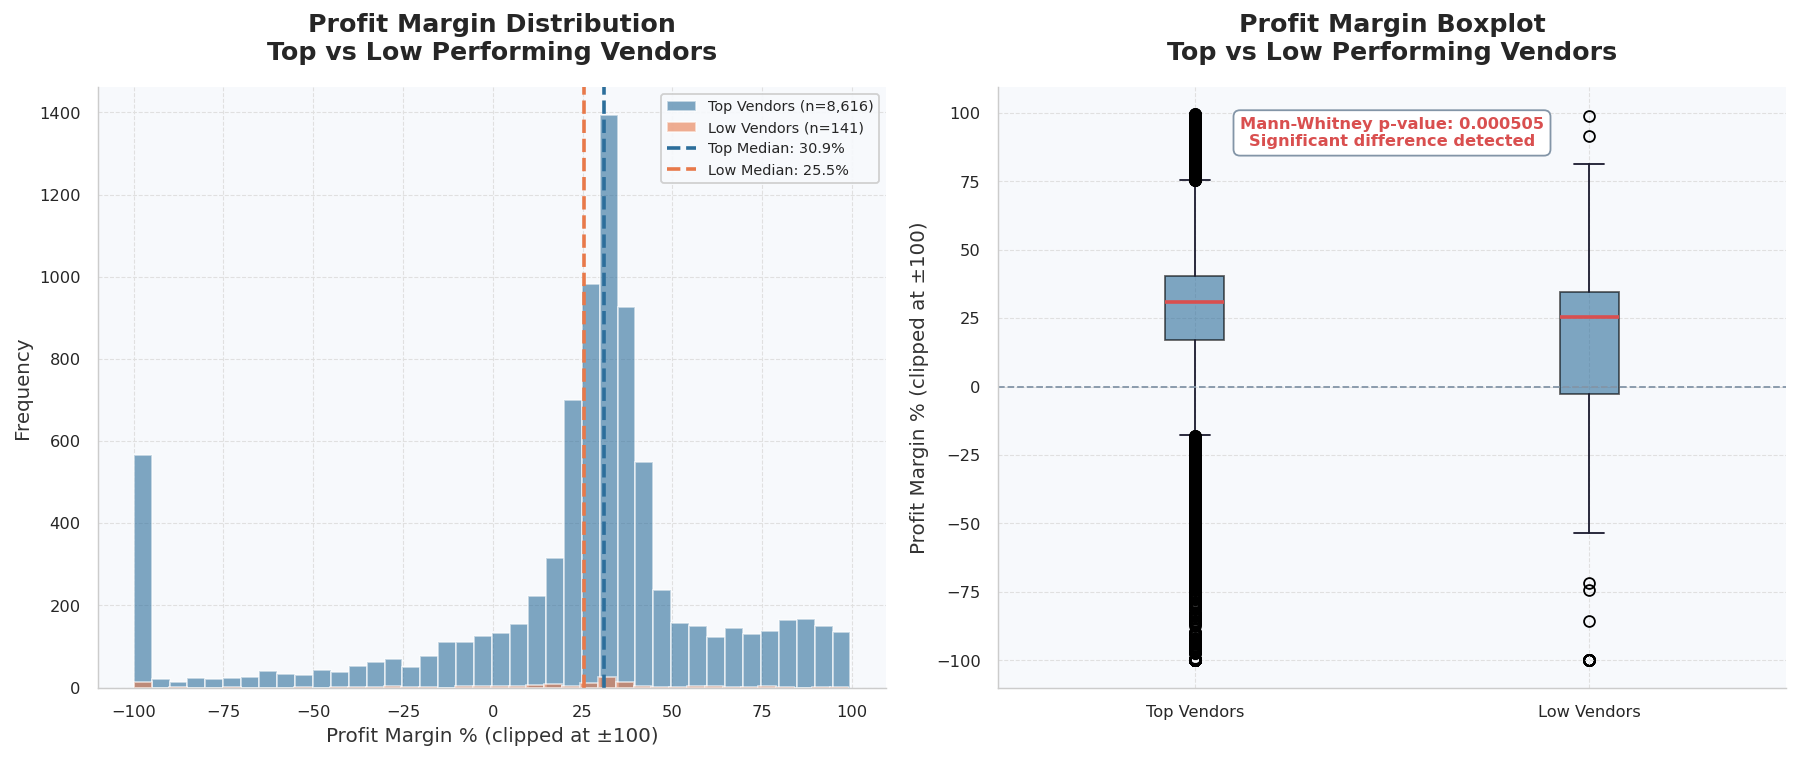

In [24]:
# ─────────────────────────────────────────────
# HYPOTHESIS TEST — VISUALIZATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Distribution comparison ──
axes[0].hist(
    top_margins.clip(-100, 100),
    bins=40, alpha=0.6,
    color=COLORS['primary'],
    label=f'Top Vendors (n={len(top_margins):,})',
    edgecolor='white'
)
axes[0].hist(
    low_margins.clip(-100, 100),
    bins=40, alpha=0.6,
    color=COLORS['secondary'],
    label=f'Low Vendors (n={len(low_margins):,})',
    edgecolor='white'
)
axes[0].axvline(top_margins.median(),
                color=COLORS['primary'],
                linestyle='--', linewidth=2,
                label=f'Top Median: {top_margins.median():.1f}%')
axes[0].axvline(low_margins.median(),
                color=COLORS['secondary'],
                linestyle='--', linewidth=2,
                label=f'Low Median: {low_margins.median():.1f}%')
axes[0].set_title('Profit Margin Distribution\nTop vs Low Performing Vendors')
axes[0].set_xlabel('Profit Margin % (clipped at ±100)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

# ── Chart 2: Box plot comparison ──
axes[1].boxplot(
    [top_margins.clip(-100, 100),
     low_margins.clip(-100, 100)],
    labels=['Top Vendors', 'Low Vendors'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['primary'], alpha=0.6),
    medianprops=dict(color=COLORS['danger'], linewidth=2),
    whiskerprops=dict(color=COLORS['dark']),
    capprops=dict(color=COLORS['dark'])
)
axes[1].set_title('Profit Margin Boxplot\nTop vs Low Performing Vendors')
axes[1].set_ylabel('Profit Margin % (clipped at ±100)')
axes[1].axhline(0, color=COLORS['muted'],
                linestyle='--', linewidth=1)

# Add p-value annotation
axes[1].text(
    0.5, 0.95,
    f'Mann-Whitney p-value: {p_value:.6f}\n'
    f'{"Significant difference detected" if p_value < 0.05 else "No significant difference"}',
    transform=axes[1].transAxes,
    ha='center', va='top', fontsize=9,
    color=COLORS['danger'] if p_value < 0.05 else COLORS['success'],
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='white', edgecolor=COLORS['muted'])
)

plt.tight_layout()
plt.show()

In [25]:
# ─────────────────────────────────────────────
# CONFIDENCE INTERVAL COMPARISON
# ─────────────────────────────────────────────

def confidence_interval(data, confidence=0.95):
    """Calculate confidence interval for the median."""
    n    = len(data)
    mean = data.mean()
    se   = stats.sem(data)
    ci   = stats.t.interval(confidence, df=n-1, loc=mean, scale=se)
    return mean, ci[0], ci[1]

top_mean, top_lower, top_upper = confidence_interval(top_margins)
low_mean, low_lower, low_upper = confidence_interval(low_margins)

print("=== 95% Confidence Intervals ===\n")
print(f"Top Vendors: Mean={top_mean:.2f}%, "
      f"CI=({top_lower:.2f}%, {top_upper:.2f}%)")
print(f"Low Vendors: Mean={low_mean:.2f}%, "
      f"CI=({low_lower:.2f}%, {low_upper:.2f}%)")
print(f"\nIntervals overlap: "
      f"{'Yes' if top_lower < low_upper and low_lower < top_upper else 'No'}")

=== 95% Confidence Intervals ===

Top Vendors: Mean=-15.86%, CI=(-25.88%, -5.84%)
Low Vendors: Mean=-38.23%, CI=(-81.40%, 4.94%)

Intervals overlap: Yes


#### Key Findings — Hypothesis Testing

- **H₀ is rejected** — p-value of 0.000505 confirms a statistically 
  significant difference in profit margins between top and low vendors
- **However the confidence intervals overlap** — meaning the difference, 
  while statistically significant, is not dramatically large in practice
- **Median margins tell the cleaner story:**
  - Top vendors: 30.92% median margin
  - Low vendors: 25.54% median margin
  - Difference of ~5.4 percentage points
- **Mean margins are misleading for both groups** — extreme outliers 
  are pulling both means deeply negative. This reinforces our earlier 
  decision to use median rather than mean for margin reporting
- **Practical implication:** Top vendors achieve higher margins partly 
  because of scale — larger volumes allow better purchasing terms and 
  more consistent pricing

## 7. Analysis Summary & Conclusions

A consolidated summary of all key findings from this vendor performance analysis.

### Financial Performance
| Metric | Value |
|---|---|
| Total Revenue | 451.6M dollars |
| Total Gross Profit | 130M dollars (28.8% margin) |
| Total Net Profit | 128.4M dollars |
| Total Excise Tax | 19M dollars |
| Freight as % of Revenue | 0.362% |

### Vendor Insights
| Finding | Detail |
|---|---|
| Revenue concentration | 17 vendors (13.5%) drive 80% of revenue |
| Top vendor | DIAGEO at 67.99M dollars revenue (15.22% share) |
| Most efficient large vendor | CONSTELLATION BRANDS — high revenue AND high margin |
| Best margin vendor | KOBRAND CORPORATION at 42.3% median margin |
| Most overstocked | STOLI GROUP at 0.866 stock turnover |
| Most underperforming SKUs | FREDERICK WILDMAN — 33% of portfolio underperforming |

### Key Recommendations
| Priority | Recommendation |
|---|---|
| High | Review purchasing volumes for STOLI, PERFECTA, WILLIAM GRANT |
| High | Grow relationship with CONSTELLATION BRANDS — best scale + margin combo |
| Medium | Investigate FREDERICK WILDMAN SKU rationalisation |
| Medium | Explore volume growth with high-margin wine vendors (KOBRAND, TREASURY) |
| Low | Freight optimisation is not a priority — costs already minimal at 0.36% |

### Statistical Finding
- Top vendors achieve **30.92% median margin** vs **25.54%** for low vendors
- Difference is statistically significant (Mann-Whitney p=0.000505)
- Median should always be used over mean due to extreme outliers in this dataset

In [26]:
# ─────────────────────────────────────────────
# CLOSE CONNECTION
# ─────────────────────────────────────────────

conn.close()
print("Analysis complete — database connection closed.")
print("Next step: Power BI Dashboard using outputs/vendor_sales_summary.csv")

Analysis complete — database connection closed.
Next step: Power BI Dashboard using outputs/vendor_sales_summary.csv
